# Nius
Load Nius CSV files and create a DataFrame named `df`.

In [37]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Nius"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
pd.reset_option('display.max_colwidth')
df.head()


Loaded 4885 rows from 285 file(s) in /Users/katinkakurz/projects/Thesis/data/raw/Alternative Medien/Nius


,id,title,titleHtml,intro,articleRef,categoryRef,articleAltRef,images,tags,video,...,isPaidContent,isTopClickModule,topClickCustomContent,showSystemTeaserTitle,meta,url,day,article_text,source,source_file
0,0682defd-0f5f-4469-812b-20d7cca70273,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,<span>Zitter-Wahl oder Durchmarsch: Wie sicher...,NaN,/politik/news/zitter-wahl-oder-durchmarsch-wie...,/politik,/articles/zitter-wahl-oder-durchmarsch-wie-sic...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,"{'title': ""Zitter-Wahl oder Durchmarsch: Wie s...",https://www.nius.de/politik/news/zitter-wahl-o...,2025-05-01,# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,Nius,nius_2025-05-01.csv
1,53d0259d-761e-4377-84b8-12185aaf54e8,"Erst fällt die Brandmauer, dann fließen Tränen...","<span>Erst fällt die Brandmauer, dann fließen ...",NaN,/gesellschaft/news/brandmauer-wurzen-demokrati...,/gesellschaft,/articles/brandmauer-wurzen-demokratie-netzwer...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,"{'title': 'Erst fällt die Brandmauer, dann fli...",https://www.nius.de/gesellschaft/news/brandmau...,2025-05-01,"# Erst fällt die Brandmauer, dann fließen Trän...",Nius,nius_2025-05-01.csv
2,4535cc72-254b-4fd5-a7b6-24a24de52784,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",<span>Als Merkel noch mal „Wir schaffen das“ s...,NaN,/gesellschaft/news/angela-merkel-evangelischer...,/gesellschaft,/articles/angela-merkel-evangelischer-kirchent...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,{'title': 'Als Merkel noch mal „Wir schaffen d...,https://www.nius.de/gesellschaft/news/angela-m...,2025-05-01,"# Als Merkel noch mal „Wir schaffen das“ sagt,...",Nius,nius_2025-05-01.csv
3,3c62c613-6cb8-49da-a8f6-c3727a9e55b6,Absage an Transideologie: Englischer Fußballve...,<span>Absage an Transideologie: Englischer Fuß...,NaN,/sport/news/absage-an-transideologie-englische...,/sport,/articles/absage-an-transideologie-englischer-...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,{'title': 'Absage an Transideologie: Englische...,https://www.nius.de/sport/news/absage-an-trans...,2025-05-01,# Absage an Transideologie: Englischer Fußball...,Nius,nius_2025-05-01.csv
4,152af3f3-137d-4a51-8f8c-5bf8c5cdbe8b,Ex-Briten-Premier Tony Blair: Bisherige Klima...,<span>Ex-Briten-Premier Tony Blair: Bisherige...,NaN,/politik/news/ex-briten-premier-tony-blair-bis...,/politik,/articles/ex-briten-premier-tony-blair-bisheri...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,{'title': 'Ex-Briten-Premier Tony Blair: Bish...,https://www.nius.de/politik/news/ex-briten-pre...,2025-05-01,# Ex-Briten-Premier Tony Blair: Bisherige Klim...,Nius,nius_2025-05-01.csv


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4885 entries, 0 to 4884
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4885 non-null   object 
 1   title                  4885 non-null   object 
 2   titleHtml              4885 non-null   object 
 3   intro                  3 non-null      object 
 4   articleRef             4885 non-null   object 
 5   categoryRef            4885 non-null   object 
 6   articleAltRef          4885 non-null   object 
 7   images                 4885 non-null   object 
 8   tags                   4885 non-null   object 
 9   video                  0 non-null      float64
 10  categories             4885 non-null   object 
 11  slug                   4885 non-null   object 
 12  lastModified           4885 non-null   object 
 13  created                4885 non-null   object 
 14  publishedAt            4885 non-null   object 
 15  temp

## Data Cleaning

In [47]:
df_clean = df[['title', 'categories', 'day', 'authors', 'article_text', 'url']].copy()
df_clean.head()

,title,categories,day,authors,article_text,url
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,"[{'id': '644a4264f03076c588c3da92', 'email': '...",# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,"[{'id': '64ac16eb3450f0e44302535e', 'email': '...","# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,"[{'id': '644f639cf03076c588c404f5', 'email': '...","# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,"[{'id': '644f639cf03076c588c404f5', 'email': '...",# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,"[{'id': '644a43e2f03076c588c3dad6', 'email': '...",# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...


In [48]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4885 entries, 0 to 4884
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         4885 non-null   object
 1   categories    4885 non-null   object
 2   day           4885 non-null   object
 3   authors       4885 non-null   object
 4   article_text  4872 non-null   object
 5   url           4885 non-null   object
dtypes: object(6)
memory usage: 229.1+ KB


In [49]:
# If previously created duplicated uppercase columns, remove them first
cols_upper = ["Title", "Text", "Date", "Authors", "Categories", "URL"]
df_clean = df_clean.drop(columns=[c for c in cols_upper if c in df_clean.columns], errors="ignore")

# Rename existing columns instead of creating new ones
df_clean = df_clean.rename(columns={
    "title": "Title",
    "article_text": "Text",
    "day": "Date",
    "authors": "Authors",
    "categories": "Categories",
    "url": "URL",
})

# Type cleanup
df_clean["Title"] = df_clean["Title"].astype(str)
df_clean["Text"] = df_clean["Text"].astype(str)
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")
df_clean["Authors"] = df_clean["Authors"].astype(str)
df_clean["Categories"] = df_clean["Categories"].astype(str)
df_clean["URL"] = df_clean["URL"].astype(str)

In [50]:
df_clean

,Title,Categories,Date,Authors,Text,URL
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,"[{'id': '644a4264f03076c588c3da92', 'email': '...",# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,"[{'id': '64ac16eb3450f0e44302535e', 'email': '...","# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,"[{'id': '644f639cf03076c588c404f5', 'email': '...","# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,"[{'id': '644f639cf03076c588c404f5', 'email': '...",# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,"[{'id': '644a43e2f03076c588c3dad6', 'email': '...",# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...
...,...,...,...,...,...,...
4880,Crews der Lufthansa gehen am Donnerstag in den...,['Wirtschaft'],2026-02-10,"[{'id': '644f639cf03076c588c404f5', 'email': '...",# Crews der Lufthansa gehen am Donnerstag in d...,https://www.nius.de/wirtschaft/news/crews-der-...
4881,Aus dem Ghetto in den Rap-Olymp: Wie Nicki Min...,['Gesellschaft'],2026-02-10,"[{'id': '695b9af7c942967b5c6b9f8f', 'email': '...",# Aus dem Ghetto in den Rap-Olymp: Wie Nicki M...,https://www.nius.de/gesellschaft/news/ikone-ni...
4882,Das war NIUS Live am Mittwoch: Jetzt wackelt T...,['NIUS Live'],2026-02-10,"[{'id': '644f639cf03076c588c404f5', 'email': '...",# Das war NIUS Live am Mittwoch: Jetzt wackelt...,https://www.nius.de/nius-live/news/nius-live-j...
4883,Lüge über Epstein-Insel: Jetzt wackelt Trumps ...,['Ausland'],2026-02-10,"[{'id': '6551f4bc3064a95275381727', 'email': '...",# Lüge über Epstein-Insel: Jetzt wackelt Trump...,https://www.nius.de/ausland/news/luege-ueber-e...


In [51]:
nan_counts = df_clean.isna().sum()
total_nans = int(nan_counts.sum())

print(f"Any NaNs in df: {total_nans > 0}")
print(f"Total NaN values: {total_nans}")

Any NaNs in df: False
Total NaN values: 0


In [52]:
# Clean the data by dropping rows with NaN values
df_clean = df_clean.dropna()
print(f"Rows after dropping NaNs: {len(df_clean)}")

Rows after dropping NaNs: 4885


Duplicates

In [53]:
# Find duplicates (mark all members of each duplicate group)
dup_title_mask = df_clean.duplicated(subset=["Title"], keep=False)
dup_text_mask = df_clean.duplicated(subset=["Text"], keep=False)
rows_to_drop_mask = dup_title_mask | dup_text_mask

print(f"Rows with duplicate titles: {dup_title_mask.sum()}")
print(f"Rows with duplicate text: {dup_text_mask.sum()}")
print(f"Total rows to drop (title OR text duplicates): {rows_to_drop_mask.sum()}")

# Drop all rows that have duplicate title or duplicate text
df_clean = df_clean.loc[~rows_to_drop_mask].copy()

print(f"Rows remaining after drop: {len(df_clean)}")


Rows with duplicate titles: 2
Rows with duplicate text: 15
Total rows to drop (title OR text duplicates): 17
Rows remaining after drop: 4868


Clean author name column

In [57]:
#Clean author name
import re

def extract_author_name(authors_str):
    """Extract author name(s) from the authors column."""
    if pd.isna(authors_str) or authors_str is None:
        return None
    
    # Convert to string if not already
    authors_str = str(authors_str)
    
    # Use regex to extract all 'name': 'value' patterns directly
    matches = re.findall(r"'name':\s*'([^']*)'", authors_str)
    if matches:
        return ', '.join(matches)
    
    # Try double quotes as well
    matches = re.findall(r'"name":\s*"([^"]*)"', authors_str)
    if matches:
        return ', '.join(matches)
    
    return None

# Apply to the dataframe
df_clean['Authors'] = df_clean['Authors'].apply(extract_author_name)
df_clean.head()
   

,Title,Categories,Date,Authors,Text,URL
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,None,# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,None,"# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,None,"# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,None,# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,None,# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...


In [10]:
#pd.set_option('display.max_colwidth', None)
df_clean.head(5)

,Title,Categories,Date,Authors,Text,URL
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,Ralf Schuler,# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,Marc Sierzputowski,"# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,Redaktion,"# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,Redaktion,# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,Julius Böhm,# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...


In [58]:
def remove_trailing_nius_reference(text):
    """Remove trailing 'Mehr NIUS:', 'Auch bei NIUS:', etc. from article text."""
    if pd.isna(text) or text is None:
        return text
    
    # Pattern to match trailing NIUS references at the end of the text
    # Matches variations like "Mehr NIUS:", "Mehr bei NIUS:", "Auch bei NIUS:", etc.
    # followed by any remaining text until the end
    pattern = r'\n*(?:Mehr|Auch|Lesen\s+[Ss]ie\s+auch)\s+(?:bei\s+)?NIUS\s*:.*$'
    
    cleaned = re.sub(pattern, '', str(text), flags=re.IGNORECASE | re.DOTALL)
    return cleaned.strip()

df_clean['Text'] = df_clean['Text'].apply(remove_trailing_nius_reference)
df_clean.head(10)

,Title,Categories,Date,Authors,Text,URL
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,None,# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,None,"# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,None,"# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,None,# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,None,# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...
5,„Wir neigen zu fürchterlicher Herablassung“: H...,"['Schuler! Fragen, was ist']",2025-05-01,None,# „Wir neigen zu fürchterlicher Herablassung“:...,"https://www.nius.de/schuler!-fragen,-was-ist/n..."
6,US-Außenminister Marco Rubio folgt auf gefeuer...,['Ausland'],2025-05-01,None,# US-Außenminister Marco Rubio folgt auf gefeu...,https://www.nius.de/ausland/news/us-aussenmini...
7,Schüsse und Stiche während 1. Mai-Demo: Zwei S...,['Kriminalität'],2025-05-01,None,# Schüsse und Stiche während 1. Mai-Demo: Zwei...,https://www.nius.de/kriminalitaet/news/berlin-...
8,Verurteilter IS-Unterstützer aus Syrien verlan...,['Kriminalität'],2025-05-02,None,# Verurteilter IS-Unterstützer aus Syrien verl...,https://www.nius.de/kriminalitaet/news/tischen...
9,Die linke Kaderschmiede im Innenministerium: W...,['Politik'],2025-05-02,None,# Die linke Kaderschmiede im Innenministerium:...,https://www.nius.de/politik/news/bundeszentral...


In [59]:
# Remove newline characters from article_text
df_clean['Text'] = df_clean['Text'].str.replace('\n', ' ', regex=False)
df_clean.head()

,Title,Categories,Date,Authors,Text,URL
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,None,# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,None,"# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,None,"# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,None,# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,None,# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...


Filter period

In [60]:
# Extract relevant time period
# Convert 'Date' column to datetime 
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Filter for articles from August 2025 to January 2026
start_date = '2025-08-01'
end_date = '2026-01-31'

df_clean = df_clean[(df_clean['Date'] >= start_date) & (df_clean['Date'] <= end_date)]
print(f"Rows after filtering to {start_date} - {end_date}: {len(df_clean)}")
df_clean.head()

Rows after filtering to 2025-08-01 - 2026-01-31: 3271


,Title,Categories,Date,Authors,Text,URL
1424,Das Bürgergeld-Leben der afghanischen Familie B.,['Gesellschaft'],2025-08-01,None,# Das Bürgergeld-Leben der afghanischen Famili...,https://www.nius.de/gesellschaft/news/buergerg...
1425,Die Planwirtschaft von Ursula von der Leyen ha...,['Politik'],2025-08-01,None,# Die Planwirtschaft von Ursula von der Leyen ...,https://www.nius.de/politik/news/die-planwirts...
1426,Jeder vierte Ausländer (20-25) geht nicht zu S...,['Gesellschaft'],2025-08-01,None,# Jeder vierte Ausländer (20-25) geht nicht zu...,https://www.nius.de/gesellschaft/news/jeder-vi...
1427,Polizei schickt Deutschen Schäferhund in Rente,['Kommentar'],2025-08-01,None,# Polizei schickt Deutschen Schäferhund in Ren...,https://www.nius.de/kommentar/news/polizei-sch...
1428,Kosovo-Clan schlägt Frau auf offener Straße zu...,['Kriminalität'],2025-08-01,None,# Kosovo-Clan schlägt Frau auf offener Straße ...,https://www.nius.de/kriminalitaet/news/kosovo-...


In [61]:
df_clean['Date'].min(), df_clean['Date'].max()

(Timestamp('2025-08-01 00:00:00'), Timestamp('2026-01-31 00:00:00'))

Filter unmeaningful categories

In [62]:
df_clean['Categories'].value_counts()

Categories
['Politik']                     861
['Kommentar']                   295
['Wirtschaft']                  263
['Kriminalität']                248
['Gesellschaft']                243
['Ausland']                     241
['Nachrichten']                 237
['NIUS Live']                   223
['Analyse']                     176
['Medien']                      159
['Kissler Kompakt']              83
['Unterhaltung']                 63
['Schuler! Fragen, was ist']     46
['Statistik']                    28
['Gio unzensiert']               19
['Interview']                    15
['Sport']                        13
[]                               13
['Berlin']                       13
['Nius Originals']               13
['Energie']                      11
['Corona']                        4
['Achtung, Reichelt!']            2
['Show']                          2
Name: count, dtype: int64

In [63]:
# Filter for rows with empty categories
empty_categories = df_clean[df_clean['Categories'] == '[]']
print(f"Number of articles with empty categories: {len(empty_categories)}")
print(f"\nPercentage of total: {len(empty_categories) / len(df_clean) * 100:.2f}%")
print(f"\nSample of articles with empty categories:")
empty_categories[['Title', 'Categories', 'Date', 'Authors','Text']].head(10)

Number of articles with empty categories: 13

Percentage of total: 0.40%

Sample of articles with empty categories:


,Title,Categories,Date,Authors,Text
1554,Trump und Putin treffen sich am Freitag in Alaska,[],2025-08-09,None,# Trump und Putin treffen sich am Freitag in A...
1896,Exklusives Gewinnspiel bei NIUS,[],2025-09-01,None,# Exklusives Gewinnspiel bei NIUS Willkommen ...
3198,Gewalt an Schulen geht durch die Decke - vor a...,[],2025-11-09,None,# Gewalt an Schulen geht durch die Decke - vor...
3209,Mann nach Festnahme wieder auf freiem Fuß: 17-...,[],2025-11-10,None,# Mann nach Festnahme wieder auf freiem Fuß: 1...
3264,Das war NIUS Live am Abend: Rentenstreit eskal...,[],2025-11-11,None,# Das war NIUS Live am Abend: Rentenstreit esk...
3631,Gründungsparteitag der AfD-Jugend in Gießen: D...,[],2025-11-28,None,# Gründungsparteitag der AfD-Jugend in Gießen:...
3746,Neue Studie: Rechtsextremismus besorgt Deutsch...,[],2025-12-07,None,# Neue Studie: Rechtsextremismus besorgt Deuts...
4051,Siemens-Bahnchef Michael Peter: Von Berlin nac...,[],2025-12-23,None,# Siemens-Bahnchef Michael Peter: Von Berlin n...
4056,„Erlauben Sie ihnen die Einreise nach Deutschl...,[],2025-12-23,None,# „Erlauben Sie ihnen die Einreise nach Deutsc...
4064,Selenskyj legt 20-Punkte-Entwurf für möglichen...,[],2025-12-24,None,# Selenskyj legt 20-Punkte-Entwurf für möglich...


In [64]:
# Filter for rows with Show categories
show_categories = df_clean[df_clean['Categories'].str.contains('Show', na=False)]
print(f"Number of articles with 'Show' category: {len(show_categories)}")
print(f"\nPercentage of total: {len(show_categories) / len(df_clean) * 100:.2f}%")
print(f"\nSample of articles with 'Show' category:")
show_categories[['Title', 'Categories', 'Date', 'Authors', 'Text']].head(10)

Number of articles with 'Show' category: 2

Percentage of total: 0.06%

Sample of articles with 'Show' category:


,Title,Categories,Date,Authors,Text
3346,Exklusiv: Frag Pauline Voss Live am Montag,['Show'],2025-11-14,None,# Exklusiv: Frag Pauline Voss Live am Montag ...
4685,Exklusiv: Grill den Reichelt Live am Donnerstag!,['Show'],2026-01-30,None,# Exklusiv: Grill den Reichelt Live am Donners...


Category 'Show' seems to be advertisement, therefore deleted from dataset

In [65]:
# Drop rows where categories contains 'Show'
df_clean = df_clean[~df_clean['Categories'].str.contains('Show', na=False)]
print(f"Rows after dropping 'Show' category: {len(df_clean)}")

Rows after dropping 'Show' category: 3269


In [69]:
nius_clean = df_clean.copy()
nius_clean['source'] = 'Nius'

nius_clean = nius_clean[['Date', 'Title', 'Text', 'source']].copy()
nius_clean.to_csv("nius_clean.csv", index=False, encoding="utf-8")

## EDA

In [19]:
# Create a table showing number of articles per month
articles_per_month = df_clean.groupby(df_clean['Date'].dt.to_period('M')).size().reset_index(name='article_count')
articles_per_month.columns = ['month', 'article_count']
articles_per_month

,month,article_count
0,2025-08,465
1,2025-09,563
2,2025-10,585
3,2025-11,601
4,2025-12,508
5,2026-01,547


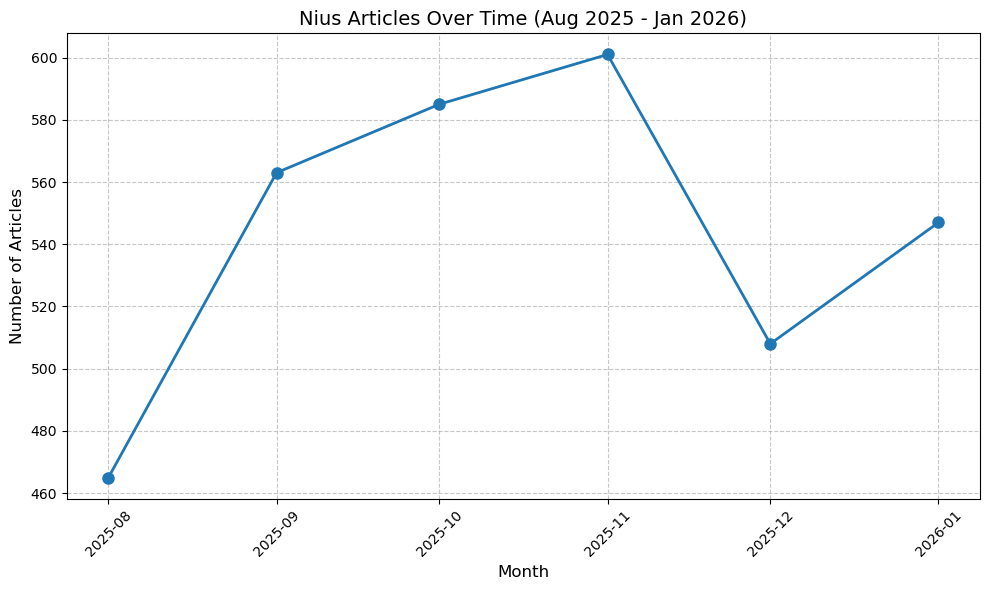

In [20]:
import matplotlib.pyplot as plt

# Create a time series plot of articles per month
fig, ax = plt.subplots(figsize=(10, 6))

# Convert period to timestamp for plotting
articles_per_month['month_ts'] = articles_per_month['month'].dt.to_timestamp()

ax.plot(articles_per_month['month_ts'], articles_per_month['article_count'], marker='o', linewidth=2, markersize=8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Nius Articles Over Time (Aug 2025 - Jan 2026)', fontsize=14)

plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [21]:
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

eda_df = df_clean.copy()
eda_df["Date"] = pd.to_datetime(eda_df["Date"], errors="coerce")

eda_df["Text"] = eda_df["Text"].astype("string")
eda_df = eda_df.dropna(subset=["Date", "Text"]).copy()

print(f"Rows used for EDA: {len(eda_df):,}")

Rows used for EDA: 3,269


In [22]:
eda_df["article_length_words"] = eda_df["Text"].str.split().str.len()
eda_df["article_length_chars"] = eda_df["Text"].str.len()

eda_df["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)

count    3269.0
mean      560.7
std       508.0
min         4.0
10%       139.0
25%       241.0
50%       418.0
75%       680.0
90%      1168.2
95%      1596.2
99%      2439.2
max      5932.0
Name: article_length_words, dtype: float64

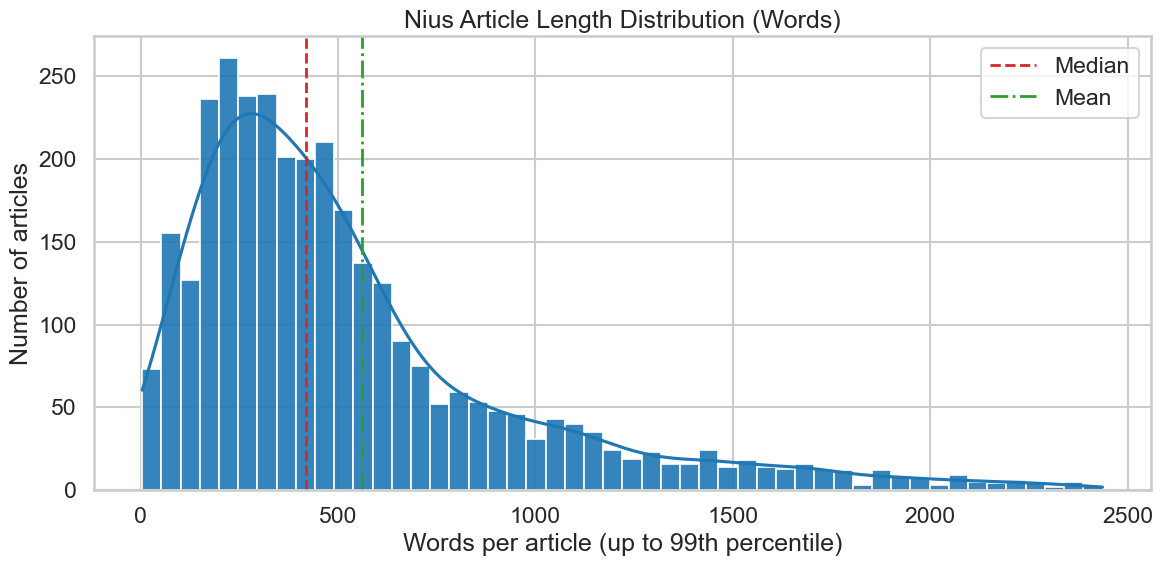

In [23]:
q99 = eda_df["article_length_words"].quantile(0.99)
length_plot = eda_df[eda_df["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(eda_df["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(eda_df["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("Nius Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
df_clean

## BERTopic

In [24]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "data preprocessing":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


In [25]:
from BERTopic.bertopic_config import BERTopicConfig
from BERTopic.bertopic_pipeline import run_bertopic_pipeline


In [26]:
df_clean

,Title,Categories,Date,Authors,Text,URL
1424,Das Bürgergeld-Leben der afghanischen Familie B.,['Gesellschaft'],2025-08-01,"Jan A. Karon, Björn Harms",# Das Bürgergeld-Leben der afghanischen Famili...,https://www.nius.de/gesellschaft/news/buergerg...
1425,Die Planwirtschaft von Ursula von der Leyen ha...,['Politik'],2025-08-01,Kurt Lauk,# Die Planwirtschaft von Ursula von der Leyen ...,https://www.nius.de/politik/news/die-planwirts...
1426,Jeder vierte Ausländer (20-25) geht nicht zu S...,['Gesellschaft'],2025-08-01,Redaktion,# Jeder vierte Ausländer (20-25) geht nicht zu...,https://www.nius.de/gesellschaft/news/jeder-vi...
1427,Polizei schickt Deutschen Schäferhund in Rente,['Kommentar'],2025-08-01,Louis Hagen,# Polizei schickt Deutschen Schäferhund in Ren...,https://www.nius.de/kommentar/news/polizei-sch...
1428,Kosovo-Clan schlägt Frau auf offener Straße zu...,['Kriminalität'],2025-08-01,Helena Gebhard,# Kosovo-Clan schlägt Frau auf offener Straße ...,https://www.nius.de/kriminalitaet/news/kosovo-...
...,...,...,...,...,...,...
4698,U-Bahn-Killer Ariop A. kam über „Resettlement-...,['Gesellschaft'],2026-01-31,"Eric Steinberg, Jan A. Karon",# U-Bahn-Killer Ariop A. kam über „Resettlemen...,https://www.nius.de/gesellschaft/news/ariop-a-...
4699,Politik als Red Flag: Datingfilter wird zum Da...,['Gesellschaft'],2026-01-31,Sara Douedari,# Politik als Red Flag: Datingfilter wird zum ...,https://www.nius.de/gesellschaft/news/politik-...
4700,Aktuelle Sonntagsfrage zur Landtagswahl in Bad...,['Politik'],2026-01-31,Redaktion,# Aktuelle Sonntagsfrage zur Landtagswahl in B...,https://www.nius.de/politik/news/aktuelle-sonn...
4701,"E-Auto-Kaufprämie: Eine Mogelpackung, die kein...",['Wirtschaft'],2026-01-31,Frank W. Haubold,"# E-Auto-Kaufprämie: Eine Mogelpackung, die ke...",https://www.nius.de/wirtschaft/news/e-auto-kau...


In [27]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(),
    id_col="URL",
    source_name="Nius",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-09 15:00:16,780 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/103 [00:00<?, ?it/s]

2026-03-09 15:00:44,326 - BERTopic - Embedding - Completed ✓
2026-03-09 15:00:44,327 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 15:00:57,949 - BERTopic - Dimensionality - Completed ✓
2026-03-09 15:00:57,952 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 15:00:58,031 - BERTopic - Cluster - Completed ✓
2026-03-09 15:00:58,040 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 15:00:59,908 - BERTopic - Representation - Completed ✓


In [28]:
topic_info = result["topic_info"]
topic_info.head(30)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,891,-1_the_millionen euro_of_rechts,"[the, millionen euro, of, rechts, frauen, frie...","[# Der EU-NGO-Komplex: 2,87 Millionen Euro für..."
1,0,614,0_union_friedrich_friedrich merz_kanzler,"[union, friedrich, friedrich merz, kanzler, pa...",[# Bundeskanzler Friedrich Merz hat keine Mehr...
2,1,268,1_jährige_täter_tat_jährigen,"[jährige, täter, tat, jährigen, verletzt, opfe...","[# Neue Details zum Tag, an dem Liana ermordet..."
3,2,205,2_hamas_israel_gaza_geiseln,"[hamas, israel, gaza, geiseln, gazastreifen, j...",[# Präzisionsschlag gegen die Hamas-Führung: W...
4,3,194,3_moderator_war live_studio_radio,"[moderator, war live, studio, radio, abend, ge...",[# Das war NIUS Live am Abend: DAX-Konzerne se...
5,4,143,4_migranten_migration_2015_bürgergeld,"[migranten, migration, 2015, bürgergeld, auslä...",[# Muster-Migranten statt harter Fakten: So re...
6,5,120,5_co2_industrie_energiewende_klima,"[co2, industrie, energiewende, klima, gas, ene...","[# Hoax „Klimaneutralität“ – Alles, was man Ih..."
7,6,98,6_iran_präsident_donald_grönland,"[iran, präsident, donald, grönland, donald tru...",[# Venezuelas Diktator Maduro in Haft: Dieses ...
8,7,92,7_wegner_strom_stromausfall_çapulcu,"[wegner, strom, stromausfall, çapulcu, anschla...","[# NIUS enthüllt, wer hinter der Ideologie vom..."
9,8,92,8_ukraine_putin_russland_selenskyj,"[ukraine, putin, russland, selenskyj, treffen,...",[# Ukraine-Verhandlungen: Wie Putin mit dem Pr...


In [29]:
# pip install gensim
import re
import numpy as np
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel


def get_topic_words(topic_model, top_k=10, include_outlier=False):
    topic_info = topic_model.get_topic_info()
    topic_ids = topic_info["Topic"].tolist()
    if not include_outlier:
        topic_ids = [t for t in topic_ids if t != -1]

    topics = []
    for topic_id in topic_ids:
        terms = topic_model.get_topic(int(topic_id)) or []
        words = [w for w, _ in terms[:top_k]]
        if words:
            topics.append(words)
    return topics


def evaluate_bertopic(docs, topic_model, top_k=10):
    # 1) Topic words
    topics = get_topic_words(topic_model, top_k=top_k, include_outlier=False)
    if not topics:
        return {"coherence_npmi": np.nan, "topic_diversity": np.nan}

    # 2) Tokenize docs for coherence
    texts = [re.findall(r"(?u)\b\w\w+\b", str(doc).lower()) for doc in docs]
    dictionary = Dictionary(texts)

    # Keep only topic words that exist in corpus dictionary
    topics_for_coherence = [[w for w in t if w in dictionary.token2id] for t in topics]
    topics_for_coherence = [t for t in topics_for_coherence if len(t) >= 2]

    if not topics_for_coherence:
        coherence_npmi = np.nan
    else:
        cm = CoherenceModel(
            topics=topics_for_coherence,
            texts=texts,
            dictionary=dictionary,
            coherence="c_npmi",
        )
        coherence_npmi = cm.get_coherence()

    # 3) Topic diversity = unique words / (num_topics * top_k)
    all_words = [w for t in topics for w in t]
    topic_diversity = len(set(all_words)) / (len(topics) * top_k)

    return {
        "coherence_npmi": coherence_npmi,
        "topic_diversity": topic_diversity,
        "num_topics": len(topics),
        "top_k": top_k,
    }



# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics


{'coherence_npmi': 0.09013655534163043,
 'topic_diversity': 0.9521739130434783,
 'num_topics': 23,
 'top_k': 10}

In [30]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=15),
    id_col="URL",
    source_name="Nius",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-09 15:01:13,477 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/103 [00:00<?, ?it/s]

2026-03-09 15:01:40,575 - BERTopic - Embedding - Completed ✓
2026-03-09 15:01:40,576 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 15:01:51,678 - BERTopic - Dimensionality - Completed ✓
2026-03-09 15:01:51,680 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 15:01:51,754 - BERTopic - Cluster - Completed ✓
2026-03-09 15:01:51,758 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 15:01:53,598 - BERTopic - Representation - Completed ✓


In [31]:
topic_info = result["topic_info"]
topic_info.head(40)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1220,-1_merz_afd_spd_the,"[merz, afd, spd, the, eu, demokratie, union, p...",[# Hans-Georg Maaßen und Rainer Wendt zur inne...
1,0,194,0_live_war live_moderator_studio,"[live, war live, moderator, studio, radio, abe...",[# Das war NIUS Live am Abend: Pleiten-Rekord!...
2,1,193,1_polizei_jährige_jährigen_tat,"[polizei, jährige, jährigen, tat, verletzt, tä...",[# Bremen: Mutmaßlicher Frauenmörder gefasst –...
3,2,143,2_migranten_migration_2015_bürgergeld,"[migranten, migration, 2015, bürgergeld, auslä...",[# Muster-Migranten statt harter Fakten: So re...
4,3,120,3_co2_eu_unternehmen_industrie,"[co2, eu, unternehmen, industrie, milliarden, ...","[# Politisch gewollt, ökonomisch verheerend: W..."
5,4,92,4_wegner_strom_stromausfall_çapulcu,"[wegner, strom, stromausfall, çapulcu, anschla...",[# Wegner lobt sich nach Terror-Blackout selbs...
6,5,85,5_hamas_israel_gaza_geiseln,"[hamas, israel, gaza, geiseln, gazastreifen, i...",[# Relativierungen und Falschaussagen: BBC-Erk...
7,6,81,6_kirk_charlie_charlie kirk_kirks,"[kirk, charlie, charlie kirk, kirks, robinson,...","[# Krieg gegen Konservative – Ruhe in Frieden,..."
8,7,72,7_merz_friedrich_friedrich merz_kanzler,"[merz, friedrich, friedrich merz, kanzler, bun...",[# Enthüllt! Merz-Haushalt ist verfassungswidr...
9,8,69,8_ukraine_putin_russland_trump,"[ukraine, putin, russland, trump, selenskyj, t...",[# Ukraine-Verhandlungen: Wie Putin mit dem Pr...


In [32]:
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics

{'coherence_npmi': 0.08363961685736022,
 'topic_diversity': 0.8219512195121951,
 'num_topics': 41,
 'top_k': 10}

In [33]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=15, max_df=0.85),
    id_col="URL",
    source_name="Nius",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-09 15:02:08,079 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/103 [00:00<?, ?it/s]

2026-03-09 15:02:34,535 - BERTopic - Embedding - Completed ✓
2026-03-09 15:02:34,536 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 15:02:45,760 - BERTopic - Dimensionality - Completed ✓
2026-03-09 15:02:45,761 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 15:02:45,830 - BERTopic - Cluster - Completed ✓
2026-03-09 15:02:45,833 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 15:02:47,769 - BERTopic - Representation - Completed ✓


In [113]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1220,-1_the_union_polizei_friedrich,"[the, union, polizei, friedrich, rechts, fried...","[# Der EU-NGO-Komplex: 1,1 Millionen Euro Steu..."
1,0,194,0_live_war live_moderator_studio,"[live, war live, moderator, studio, radio, geh...",[# Das war NIUS Live am Abend: Pleiten-Rekord!...
2,1,193,1_polizei_jährige_jährigen_tat,"[polizei, jährige, jährigen, tat, verletzt, tä...",[# Bremen: Mutmaßlicher Frauenmörder gefasst –...
3,2,143,2_migranten_migration_2015_bürgergeld,"[migranten, migration, 2015, bürgergeld, auslä...",[# Muster-Migranten statt harter Fakten: So re...
4,3,120,3_co2_industrie_milliarden_energiewende,"[co2, industrie, milliarden, energiewende, kli...",[# CO2-Preis: Die Lüge vom „marktwirtschaftlic...
5,4,92,4_wegner_strom_stromausfall_çapulcu,"[wegner, strom, stromausfall, çapulcu, anschla...",[# Wegner lobt sich nach Terror-Blackout selbs...
6,5,85,5_hamas_israel_gaza_geiseln,"[hamas, israel, gaza, geiseln, gazastreifen, i...",[# Relativierungen und Falschaussagen: BBC-Erk...
7,6,81,6_kirk_charlie_charlie kirk_kirks,"[kirk, charlie, charlie kirk, kirks, robinson,...","[# Krieg gegen Konservative – Ruhe in Frieden,..."
8,7,72,7_friedrich_friedrich merz_kanzler_bundeskanzler,"[friedrich, friedrich merz, kanzler, bundeskan...",[# Friedrich Merz ist wie eine Schachtel Prali...
9,8,69,8_ukraine_putin_russland_trump,"[ukraine, putin, russland, trump, selenskyj, t...",[# Ukraine-Verhandlungen: Wie Putin mit dem Pr...


## OLD

In [ ]:
nius_topics = df_clean.reset_index().merge(
    doc_info[["original_index", "Topic", "Name", "Probability"]],
    left_on="index",
    right_on="original_index",
    how="left",
)

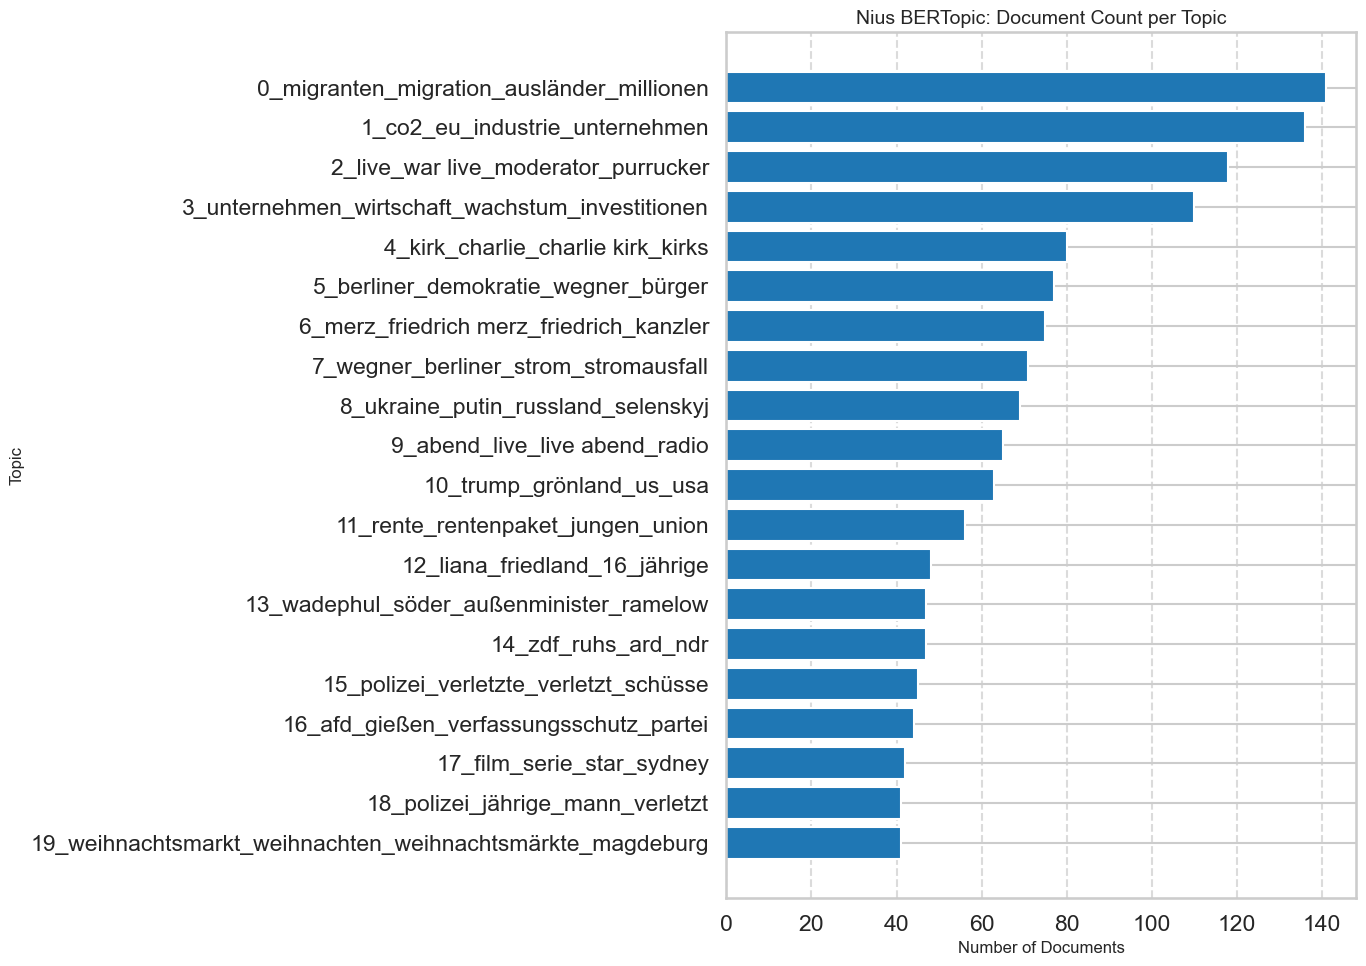

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

# Exclude topic -1 (outliers) for cleaner visualization
topic_counts = topic_info[topic_info['Topic'] != -1].copy()
topic_counts = topic_counts.nlargest(20, 'Count').sort_values('Count', ascending=True)

ax.barh(topic_counts['Name'], topic_counts['Count'], color='#1f77b4', edgecolor='white')

ax.set_xlabel('Number of Documents', fontsize=12)
ax.set_ylabel('Topic', fontsize=12)
ax.set_title('Nius BERTopic: Document Count per Topic', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

6it [00:03,  1.86it/s]


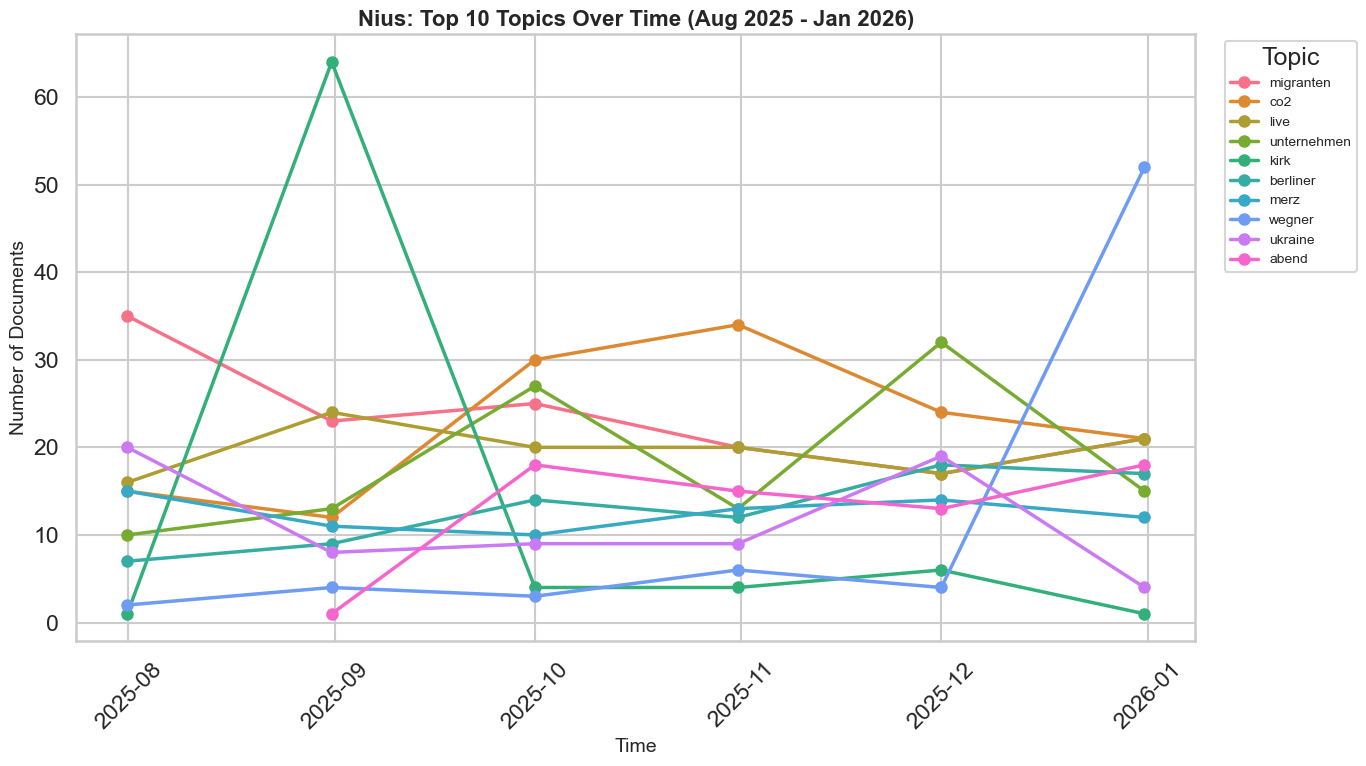

In [ ]:
# Prepare data for topics over time
topics_over_time = result["topic_model"].topics_over_time(
    result["docs"],
    result["prepared_documents"]["day"].tolist(),
    nr_bins=6
)

# Get top 10 topics by count (excluding -1)
top_10_topics = topic_info[topic_info['Topic'] != -1].nlargest(10, 'Count')['Topic'].tolist()

# Filter for top 10 topics
topics_over_time_filtered = topics_over_time[topics_over_time['Topic'].isin(top_10_topics)]

# Create topic name mapping
topic_name_map = dict(zip(topic_info['Topic'], topic_info['Name']))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered['Topic'] == topic]
    label = topic_name_map.get(topic, f"Topic {topic}")
    # Shorten label for legend
    short_label = label.split('_')[1] if '_' in label else label
    ax.plot(topic_data['Timestamp'], topic_data['Frequency'], 
            marker='o', linewidth=2.5, markersize=8, 
            color=palette[i], label=short_label)

ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Number of Documents', fontsize=14)
ax.set_title('Nius: Top 10 Topics Over Time (Aug 2025 - Jan 2026)', fontsize=16, fontweight='bold')
ax.legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
topic_info = result["topic_info"]

topic_info_view = topic_info.drop(columns=["Representative_Docs"], errors="ignore")

with pd.option_context(
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None
):
    display(topic_info_view.head(20))

BERTopic #2

In [ ]:
from transformers import pipeline
import pandas as pd

pipeline_classification_topics = pipeline(
    "text-classification",
    model="chkla/parlbert-topic-german",
    return_all_scores=False,
)

def prepare_for_classifier(text, max_chars=2000):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    # Simple truncation for first-pass testing
    return text[:max_chars]

nius_cls = df_clean.copy()
nius_cls = nius_cls.dropna(subset=["article_text"]).copy()
nius_cls["clf_input"] = nius_cls["article_text"].map(prepare_for_classifier)

predictions = []
scores = []

for text in nius_cls["clf_input"]:
    if not text:
        predictions.append(None)
        scores.append(None)
        continue
    result = pipeline_classification_topics(text)[0]
    predictions.append(result["label"])
    scores.append(result["score"])

nius_cls["parlbert_topic"] = predictions
nius_cls["parlbert_score"] = scores

nius_cls[["title", "parlbert_topic", "parlbert_score"]].head(20)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: chkla/parlbert-topic-german
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/354 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (528 > 512). Running this sequence through the model will result in indexing errors


RuntimeError: The size of tensor a (528) must match the size of tensor b (512) at non-singleton dimension 1

In [ ]:
# BERTopic v2 run: full text first, then title-only
from BERTopic.bertopic_pipelinev2 import (
    BERTopicV2Config,
    BERTopicV2ConfigTitle,
    run_bertopic_pipeline,
)

result_full_text_v2 = run_bertopic_pipeline(
    df=df_clean,
    text_col="article_text",
    config=BERTopicV2Config(),
    id_col="url",
    source_name="Nius",
)

result_title_v2 = run_bertopic_pipeline(
    df=df_clean,
    text_col="title",
    config=BERTopicV2ConfigTitle(),
    id_col="url",
    source_name="Nius",
)

print(
    f"v2 full-text docs: {len(result_full_text_v2['docs']):,} | "
    f"v2 title docs: {len(result_title_v2['docs']):,}"
)

